# **Capítulo 5: Segmentación de Imágenes con técnicas clásicas de PDI**

```
 Libro:  Procesamiento Digital de Voz e Imágenes en la Era de la Inteligencia Artificial
```


**Autor:  Dora María Ballesteros Larrotta**  
Universidad Militar Nueva Granada (UMNG)

---

### Material complementario del libro

Este notebook acompaña el **Capítulo 5** y contiene los ejemplos desarrollados a lo largo del texto. Se recomienda seguir el mismo orden del libro para obtener el máximo provecho de las actividades propuestas.

# **Ejemplo 27. Segmentación de la hoja mediante una máscara binaria en el modelo HSV**

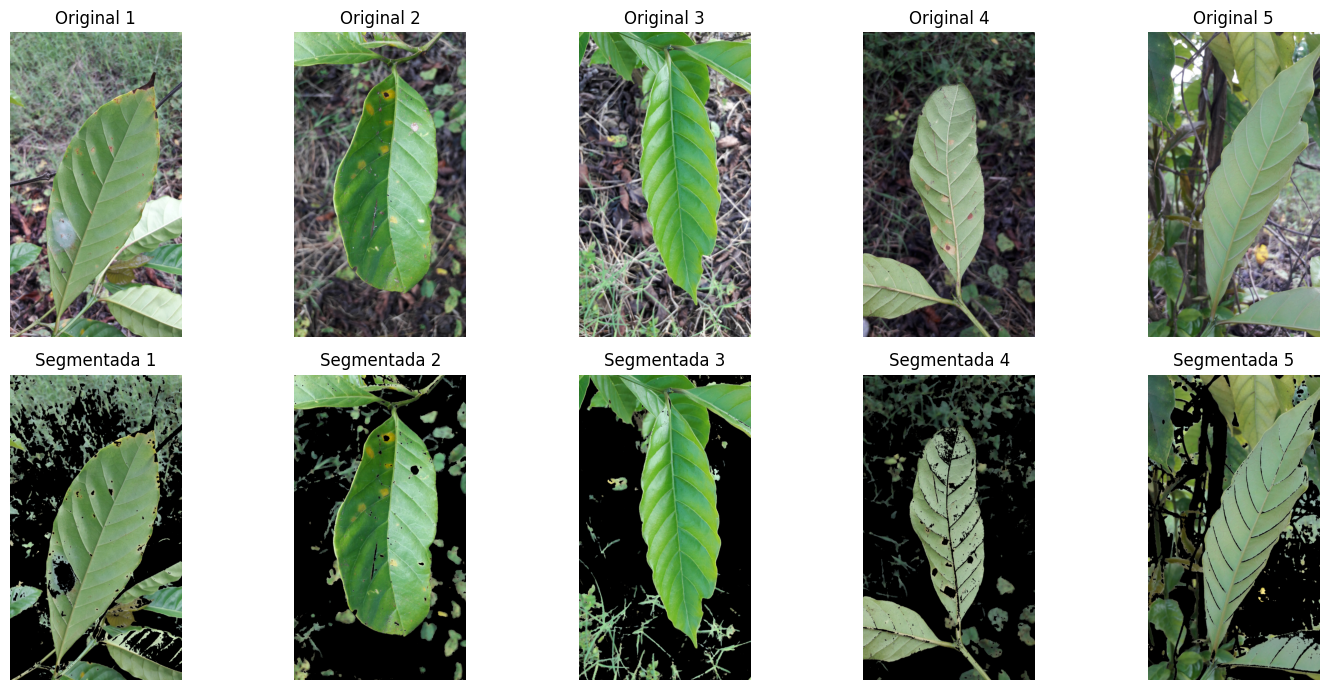

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

nombres = ["C10P11E2.jpg", "C10P10H2.jpg", "C10P10H1.jpg",
           "C10P10E2.jpg", "C10P10E1.jpg"] # Imágenes de RoCoLe

lim_inf = np.array([25, 35, 25]) # Límite inferior HSV para tonalidades verdes
lim_sup = np.array([95, 255, 255]) # Límite superior HSV para tonalidades verdes

plt.figure(figsize=(15, 7))

for i, nombre in enumerate(nombres):
    imagen_bgr = cv2.imread(nombre) # Leer imagen
    imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB) # Convertir a RGB
    imagen_hsv = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2HSV) # Convertir a HSV

    mascara = cv2.inRange(imagen_hsv, lim_inf, lim_sup) # Crear máscara binaria
    segmentada = cv2.bitwise_and(imagen_rgb, imagen_rgb, mask=mascara) # Aplicar máscara

    plt.subplot(2, 5, i + 1); plt.imshow(imagen_rgb)
    plt.title(f"Original {i + 1}"); plt.axis("off")
    plt.subplot(2, 5, i + 6); plt.imshow(segmentada)
    plt.title(f"Segmentada {i + 1}"); plt.axis("off")
plt.tight_layout(); plt.show()

# **Ejemplo 28. Segmentación de la hoja con contornos y máscara binaria en el modelo HSV**

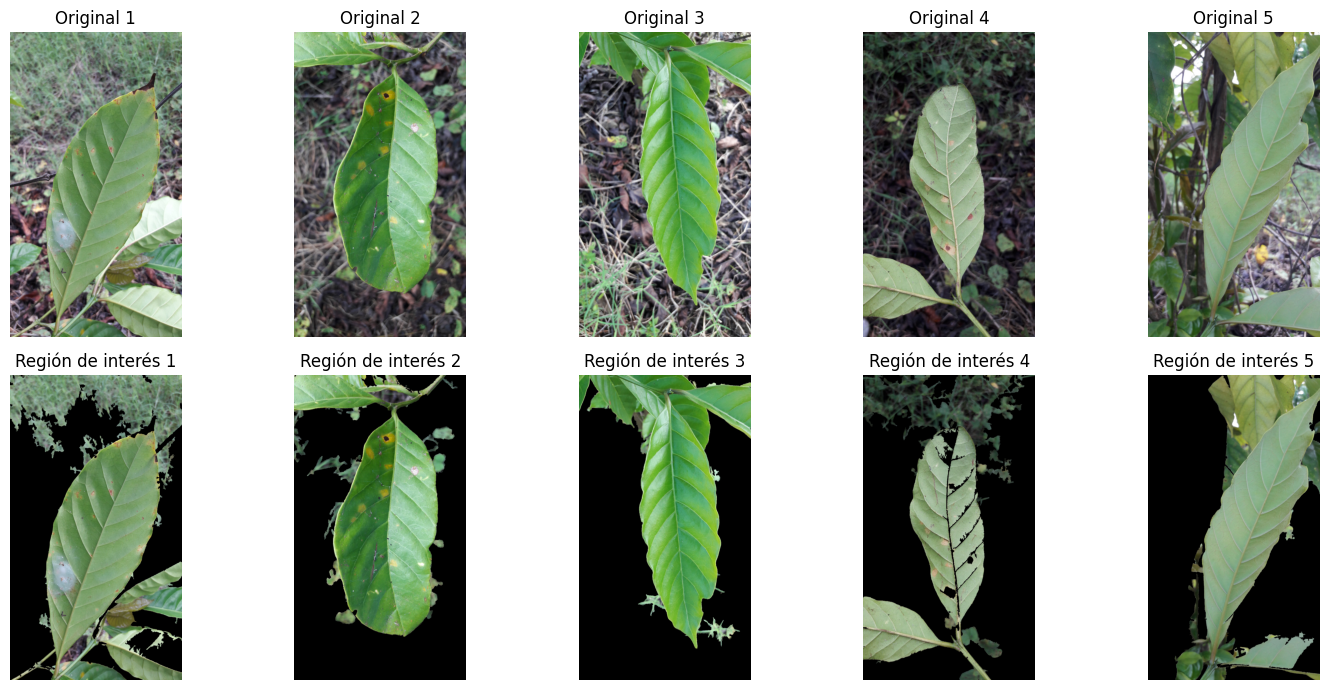

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

nombres = ["C10P11E2.jpg", "C10P10H2.jpg", "C10P10H1.jpg",
           "C10P10E2.jpg", "C10P10E1.jpg"] # Imágenes de RoCoLe

lim_inf = np.array([25, 35, 25]) # Límite inferior HSV
lim_sup = np.array([95, 255, 255]) # Límite superior HSV

plt.figure(figsize=(15, 7))

for i, nombre in enumerate(nombres):
    imagen_bgr = cv2.imread(nombre) # Leer imagen
    imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB) # Convertir a RGB
    imagen_hsv = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2HSV) # Convertir a HSV

    mascara = cv2.inRange(imagen_hsv, lim_inf, lim_sup) # Máscara inicial
    contornos, _ = cv2.findContours(mascara, cv2.RETR_EXTERNAL,
                                    cv2.CHAIN_APPROX_SIMPLE) # Encontrar regiones
    mascara_roi = np.zeros_like(mascara) # Crear máscara negra

    if contornos:
        mayor = max(contornos, key=cv2.contourArea) # Contorno de mayor área
        cv2.drawContours(mascara_roi, [mayor], -1, 255, -1) # Rellenar región
    segmentada = cv2.bitwise_and(imagen_rgb, imagen_rgb,
                                mask=mascara_roi) # Conservar hoja principal

    plt.subplot(2, 5, i + 1); plt.imshow(imagen_rgb)
    plt.title(f"Original {i + 1}"); plt.axis("off")
    plt.subplot(2, 5, i + 6); plt.imshow(segmentada)
    plt.title(f"Región de interés {i + 1}"); plt.axis("off")
plt.tight_layout(); plt.show()

# **Ejemplo 29. Segmentación de la hoja mediante contornos, operaciones morfológicas y análisis de centroides**

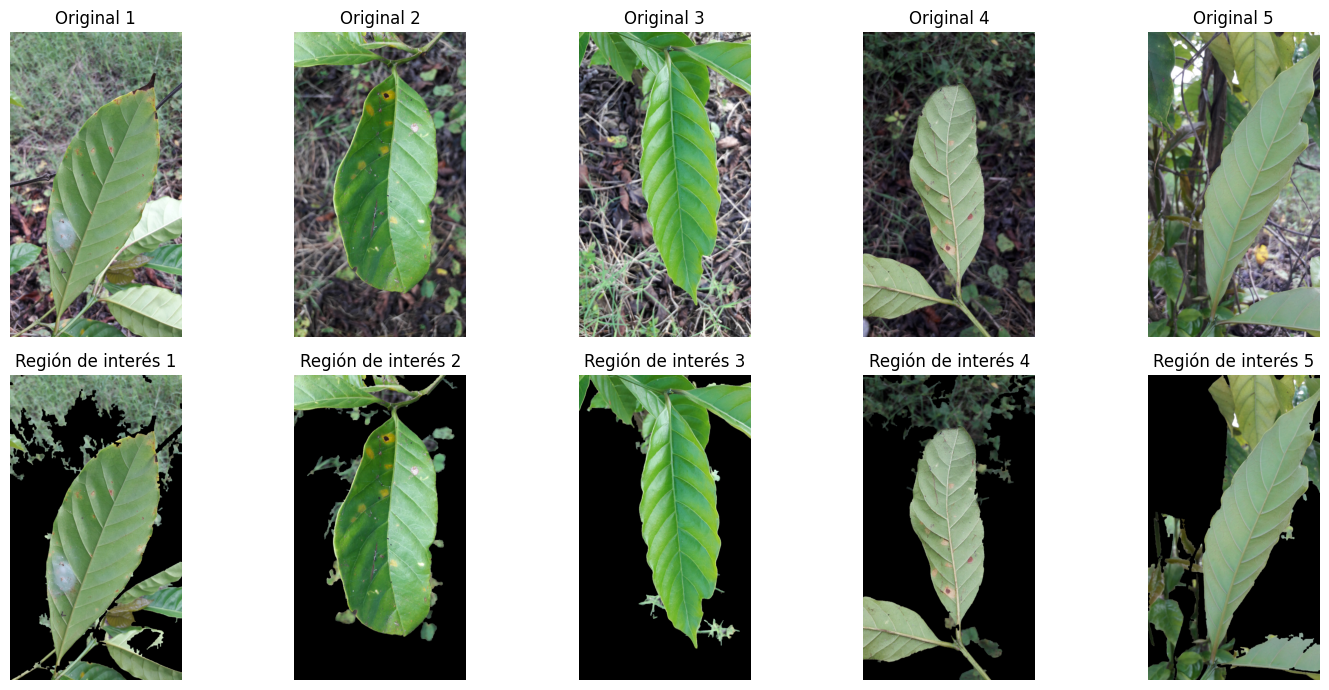

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

nombres = ["C10P11E2.jpg", "C10P10H2.jpg", "C10P10H1.jpg",
           "C10P10E2.jpg", "C10P10E1.jpg"] # Imágenes de RoCoLe

lim_inf = np.array([25, 35, 25]) # Límite inferior HSV
lim_sup = np.array([95, 255, 255]) # Límite superior HSV

plt.figure(figsize=(15, 7))

for i, nombre in enumerate(nombres):
    imagen_bgr = cv2.imread(nombre) # Leer imagen
    imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB) # Convertir a RGB
    imagen_hsv = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2HSV) # Convertir a HSV

    mascara = cv2.inRange(imagen_hsv, lim_inf, lim_sup) # Máscara inicial
    kernel = np.ones((5, 5), np.uint8)
    mascara = cv2.morphologyEx(mascara, cv2.MORPH_OPEN,
                               kernel, iterations=1) # Eliminar regiones pequeñas
    mascara = cv2.morphologyEx(mascara, cv2.MORPH_CLOSE,
                               kernel, iterations=2) # Cerrar huecos pequeños
    num, etiquetas, stats, centroides = cv2.connectedComponentsWithStats(
        mascara, connectivity=8) # Regiones conectadas

    alto, ancho = mascara.shape
    centro_img = np.array([ancho / 2, alto / 2])

    # Región central de referencia
    x1, x2 = int(0.25 * ancho), int(0.75 * ancho)
    y1, y2 = int(0.15 * alto), int(0.90 * alto)

    mejor_etiqueta = 0; mejor_puntaje = 0

    for j in range(1, num):
        x, y, w, h, area = stats[j]
        centro = centroides[j]

        region = etiquetas == j
        pixeles_centrales = np.sum(region[y1:y2, x1:x2])
        proporcion_central = pixeles_centrales / max(area, 1)

        distancia = np.linalg.norm(centro - centro_img)
        cercania = 1 / (1 + distancia)

        toca_borde = x == 0 or y == 0 or x + w >= ancho or y + h >= alto
        penalizacion = 0.40 if toca_borde else 1.0

        puntaje = area * (1 + 3 * proporcion_central) * cercania * penalizacion

        if puntaje > mejor_puntaje:
            mejor_puntaje = puntaje
            mejor_etiqueta = j

    mascara_roi = np.zeros_like(mascara)
    mascara_roi[etiquetas == mejor_etiqueta] = 255 # Conservar región seleccionada

    # Rellenar huecos internos de la hoja
    contornos, _ = cv2.findContours(mascara_roi, cv2.RETR_EXTERNAL,
                                    cv2.CHAIN_APPROX_SIMPLE)
    mascara_final = np.zeros_like(mascara_roi)

    if contornos:
        mayor = max(contornos, key=cv2.contourArea)
        cv2.drawContours(mascara_final, [mayor], -1, 255, -1)

    segmentada = cv2.bitwise_and(imagen_rgb, imagen_rgb,
                                mask=mascara_final) # Aplicar máscara

    plt.subplot(2, 5, i + 1); plt.imshow(imagen_rgb)
    plt.title(f"Original {i + 1}"); plt.axis("off")

    plt.subplot(2, 5, i + 6); plt.imshow(segmentada)
    plt.title(f"Región de interés {i + 1}"); plt.axis("off")

plt.tight_layout(); plt.show()

Libro: Procesamiento Digital de Voz e Imágenes  en la Era de la Inteligencia Artificial

---


Versión: 2026 – Material complementario para Google Colab.